Food Delivery Analytics using Python (NumPy, Pandas, Matplotlib, Seaborn, Plotly)

KPIs:
Total Sales,
Average Rating,
Average Order Value,
Total Orders,
Ratings Count


---


## Key Insights

- Top cities contribute majority of total sales.
- Ratings are mostly clustered between X–Y (based on your graph).
- Monthly trend shows peak in ___ month.
- Certain states dominate food delivery demand.


---


CHARTS:
Monthly Trend,
Daily Trend,
Veg vs Non-Veg,
State-wise Sales (MAP),
Quarterly Performance,
Top Cities,
Weekly Trends

PROJECT PIPELINE BELOW :

1. Excel → Pandas → Cleaning → Feature Engineering

---


    
2. NumPy (calculations)
       

---


3. Seaborn + Matplotlib (analysis)
       

---


4. Plotly (interactive dashboard )

In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("swiggy_data.xlsx")

df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [2]:
df.shape

(197430, 10)

In [3]:
df.columns

Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price (INR)', 'Rating', 'Rating Count'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


CLEANING

In [5]:

df.isnull().sum()

,0
State,0
City,0
Order Date,0
Restaurant Name,0
Location,0
Category,0
Dish Name,0
Price (INR),0
Rating,0
Rating Count,0


FEATURE ENGINEERING

In [6]:
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year
df['Day'] = df['Order Date'].dt.day
df['Day_Name'] = df['Order Date'].dt.day_name()

KPI CALCULATIONS

In [7]:
total_sales = df['Price (INR)'].sum()
avg_rating = df['Rating'].mean()
total_orders = len(df)
avg_order_value = df['Price (INR)'].mean()

print("Total Sales:", total_sales)
print("Avg Rating:", avg_rating)
print("Total Orders:", total_orders)
print("Avg Order Value:", avg_order_value)

Total Sales: 53012505.77000001
Avg Rating: 4.341581826470141
Total Orders: 197430
Avg Order Value: 268.51291987033386


BASIC ANALYSIS

Orders by Category

In [ ]:
df['Category'].value_counts()

Top Cities

In [ ]:
df['City'].value_counts().head(10)

SEABORN VISUALIZATION

In [11]:
df['Category'].unique()

array(['Snack', 'Recommended', 'North Indian Gravy', ..., 'Chicken Momo',
       'Chicken Rice', 'make your own combo'], dtype=object)

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 157 (\x9d) missing from font(s) DejaVu Sans.



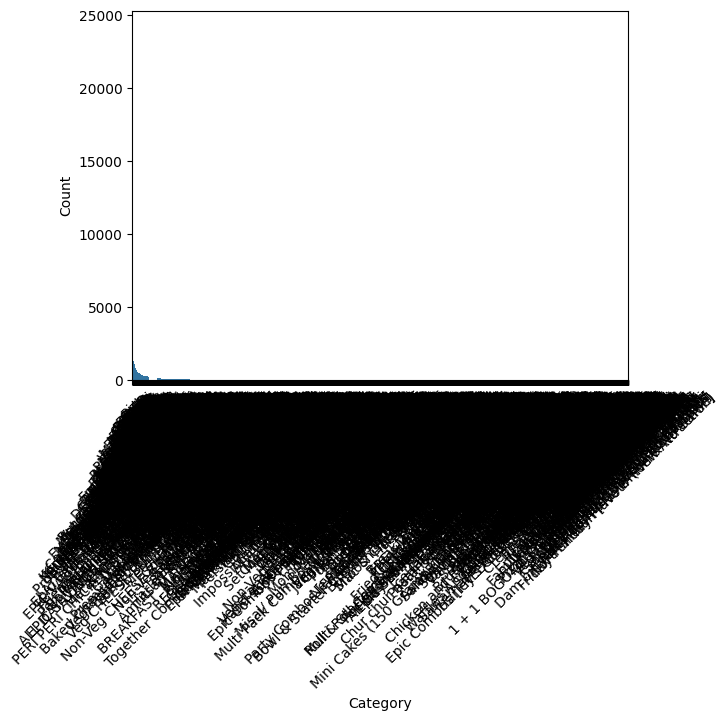

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

category_counts = df['Category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Count']

sns.barplot(x='Category', y='Count', data=category_counts)
plt.xticks(rotation=45)
plt.show()

MONTHLY TREND

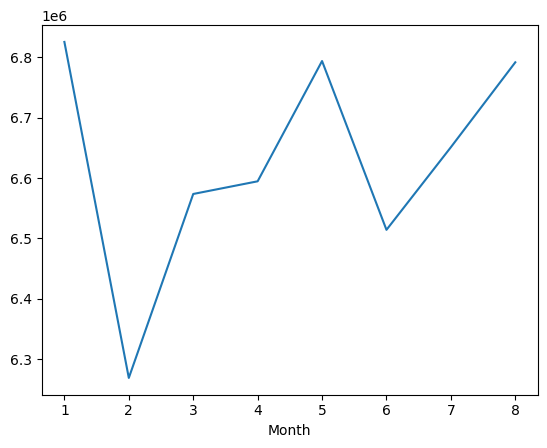

In [9]:
monthly_sales = df.groupby('Month')['Price (INR)'].sum()

monthly_sales.plot(kind='line')
plt.show()

PLOTLY

In [13]:
top_cities = df.groupby('City')['Price (INR)'].sum().sort_values(ascending=False).head(10)

import plotly.express as px

fig = px.bar(
    x=top_cities.index,
    y=top_cities.values,
    title="Top 10 Cities by Sales",
    labels={'x': 'City', 'y': 'Total Sales'}
)

fig.show()

Rating Distribution

In [14]:
fig = px.histogram(df, x='Rating', nbins=10, title='Rating Distribution')

fig.show()

MONTHLY SALES TREND

In [15]:
monthly_sales = df.groupby('Month')['Price (INR)'].sum().reset_index()

fig = px.line(
    monthly_sales,
    x='Month',
    y='Price (INR)',
    title='Monthly Sales Trend',
    markers=True
)

fig.show()

STATE-WISE SALES

In [16]:
state_sales = df.groupby('State')['Price (INR)'].sum().sort_values(ascending=False).head(10)

fig = px.bar(
    x=state_sales.index,
    y=state_sales.values,
    title="Top States by Sales"
)

fig.show()

PRICE DISTRIBUTION

In [17]:
fig = px.histogram(df, x='Price (INR)', nbins=30, title='Price Distribution')

fig.show()

Top Restaurant

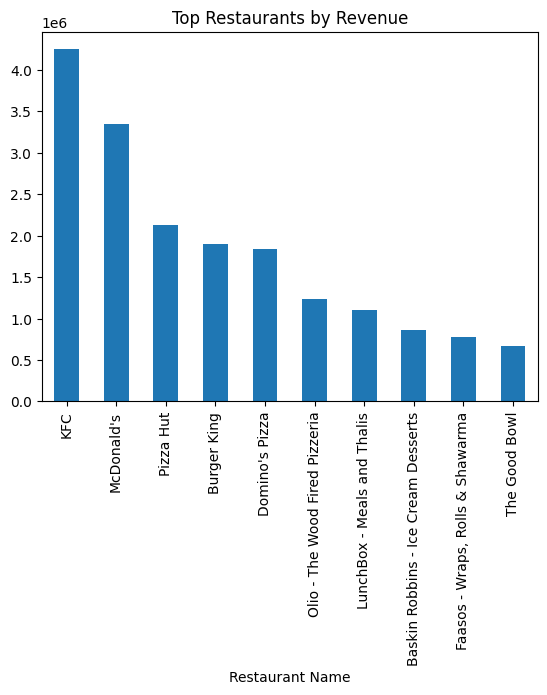

In [18]:
top_rest = df.groupby('Restaurant Name')['Price (INR)'].sum().sort_values(ascending=False).head(10)

top_rest.plot(kind='bar')
plt.title("Top Restaurants by Revenue")
plt.show()

## Conclusion

This project analyzes food delivery data using Python libraries.
It highlights sales trends, customer behavior, and geographical insights.
The use of Pandas, NumPy, Matplotlib, Seaborn, and Plotly enables both static and interactive analysis.

FULL STRUCTURE -- >
1. Objective
2. Data Loading
3. Cleaning
4. Feature Engineering
5. KPIs
6. Visualization
7. Insights
8. Conclusion